# 第6章: 単語ベクトル

# Chương 6: Vector từ (Word Vectors)


単語の意味を実ベクトルで表現する単語ベクトル（単語埋め込み）に関して、以下の処理を行うプログラムを作成せよ。

Hãy viết chương trình thực hiện các xử lý sau liên quan đến word vector (word embedding) – cách biểu diễn ý nghĩa của từ bằng vector số thực.

## 50. 単語ベクトルの読み込みと表示

Google Newsデータセット（約1,000億単語）での[学習済み単語ベクトル](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit?usp=sharing)（300万単語・フレーズ、300次元）をダウンロードし、"United States"の単語ベクトルを表示せよ。ただし、"United States"は内部的には"United_States"と表現されていることに注意せよ。


## 50. Đọc và hiển thị word vector

Hãy tải bộ word vector đã được huấn luyện trên tập dữ liệu Google News:

- khoảng 100 tỷ từ
- 3 triệu từ/cụm từ
- vector 300 chiều

Sau đó hiển thị vector của:

- United States

Lưu ý:

Trong mô hình này, cụm từ trên được lưu dưới dạng:

- United_States

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!find /content/drive/MyDrive -name "GoogleNews-vectors-negative300.bin.gz"

/content/drive/MyDrive/Colab Notebooks/nlp100/data/GoogleNews-vectors-negative300.bin.gz


In [6]:
#!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.5 MB/s eta 0:00:00


In [7]:
from pathlib import Path
from gensim.models import KeyedVectors

ROOT = Path("/content/drive/MyDrive/Colab Notebooks/nlp100")
DATA = ROOT / "data"

model_path = DATA / "GoogleNews-vectors-negative300.bin.gz"

model = KeyedVectors.load_word2vec_format(
    model_path,
    binary=True
)

vector = model["United_States"]

print(vector[:10])

[-0.03613281 -0.04833984  0.23535156  0.17480469 -0.14648438 -0.07421875
 -0.1015625  -0.07714844  0.109375   -0.05712891]


## 51. 単語の類似度

"United States"と"U.S."のコサイン類似度を計算せよ。

## 51. Độ tương đồng giữa hai từ

Hãy tính cosine similarity giữa:

- United States

và

- U.S.

In [8]:
# version 1

import numpy as np

v1 = model["United_States"]
v2 = model["U.S."]

similarity = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

print(similarity)

0.7310775


In [9]:
model.similarity("United_States", "U.S.")

np.float32(0.73107743)

## 52. 類似度の高い単語10件

"United States"とコサイン類似度が高い10語と、その類似度を出力せよ。

## 52. 10 từ giống nhất

Hãy tìm:

- 10 từ có cosine similarity cao nhất với
  - United States
- cùng với giá trị similarity tương ứng.

In [10]:
import numpy as np

target = model["United_States"]

results = []

for word in model.index_to_key:
    if word == "United_States":
        continue

    vec = model[word]

    similarity = np.dot(target, vec) / (np.linalg.norm(target) * np.linalg.norm(vec))

    results.append((word, similarity))

results.sort(key=lambda x: x[1], reverse=True)

for word, score in results[:10]:
    print(word, score)

Unites_States 0.7877249
Untied_States 0.754137
United_Sates 0.7400725
U.S. 0.7310775
theUnited_States 0.64043945
America 0.61784106
UnitedStates 0.61673117
Europe 0.6132989
countries 0.60448045
Canada 0.60190696


In [11]:
model.most_similar("United_States", topn=10)

[('Unites_States', 0.7877248525619507),
 ('Untied_States', 0.7541370987892151),
 ('United_Sates', 0.7400724291801453),
 ('U.S.', 0.7310774326324463),
 ('theUnited_States', 0.6404393911361694),
 ('America', 0.6178410053253174),
 ('UnitedStates', 0.6167312264442444),
 ('Europe', 0.6132988929748535),
 ('countries', 0.6044804453849792),
 ('Canada', 0.601906955242157)]

## 53. 加法構成性によるアナロジー

"Spain"の単語ベクトルから"Madrid"のベクトルを引き、"Athens"のベクトルを足したベクトルを計算し、そのベクトルと類似度の高い10語とその類似度を出力せよ。


## 53. Phép suy luận tương tự bằng phép cộng vector

Hãy tính vector:

- vec(Spain)−vec(Madrid)+vec(Athens)

Sau đó:

- tìm 10 từ gần vector này nhất
- hiển thị các từ đó và độ tương đồng tương ứng.

In [12]:
import numpy as np

query = (model["Spain"]- model["Madrid"]+ model["Athens"])

results = []

for word in model.index_to_key:
    if word in {"Spain", "Madrid", "Athens"}:
        continue

    vec = model[word]

    similarity = np.dot(query, vec) / (np.linalg.norm(query) * np.linalg.norm(vec))

    results.append((word, similarity))

results.sort(key=lambda x: x[1], reverse=True)

for word, score in results[:10]:
    print(word, score)

Greece 0.6685472
Aristeidis_Grigoriadis 0.54957783
Ioannis_Drymonakos 0.53614575
Greeks 0.5351787
Ioannis_Christou 0.5330226
Hrysopiyi_Devetzi 0.50884897
Iraklion 0.5059265
Greek 0.5040616
Athens_Greece 0.503411
Heraklio 0.498769


In [13]:
model.most_similar(
    positive=["Athens", "Spain"],
    negative=["Madrid"],
    topn=10
)

[('Greece', 0.6898480653762817),
 ('Aristeidis_Grigoriadis', 0.560684859752655),
 ('Ioannis_Drymonakos', 0.5552908778190613),
 ('Greeks', 0.545068621635437),
 ('Ioannis_Christou', 0.5400862097740173),
 ('Hrysopiyi_Devetzi', 0.5248444676399231),
 ('Heraklio', 0.5207759737968445),
 ('Athens_Greece', 0.516880989074707),
 ('Lithuania', 0.5166865587234497),
 ('Iraklion', 0.5146791338920593)]

## 54. アナロジーデータでの実験

[単語アナロジーの評価データ](http://download.tensorflow.org/data/questions-words.txt)をダウンロードし、国と首都に関する事例（`: capital-common-countries`セクション）に対して、vec(2列目の単語) - vec(1列目の単語) + vec(3列目の単語)を計算し、そのベクトルと類似度が最も高い単語と、その類似度を求めよ。求めた単語と類似度は、各事例と一緒に記録せよ。

## 54. Thí nghiệm trên tập dữ liệu analogy

Hãy tải bộ dữ liệu đánh giá word analogy.

Đối với phần:

- capital-common-countries

(thủ đô và quốc gia)

Với mỗi bộ:

- a b c d

hãy tính:

- vec(b)−vec(a)+vec(c)

Sau đó:

- tìm từ gần nhất với vector kết quả
- ghi lại:
  - bài toán gốc
  - từ dự đoán
  - similarity

In [14]:
!wget http://download.tensorflow.org/data/questions-words.txt

--2026-06-07 13:04:36--  http://download.tensorflow.org/data/questions-words.txt
Resolving download.tensorflow.org (download.tensorflow.org)... 108.177.98.207, 74.125.135.207, 172.253.117.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|108.177.98.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 603955 (590K) [text/plain]
Saving to: ‘questions-words.txt’

questions-words.txt 100%[===================>] 589.80K  --.-KB/s    in 0.004s  

2026-06-07 13:04:37 (137 MB/s) - ‘questions-words.txt’ saved [603955/603955]



In [15]:
!ls

drive  questions-words.txt  sample_data


In [16]:
with open("questions-words.txt", "r") as f:
    for _ in range(20):
        print(f.readline().strip())

: capital-common-countries
Athens Greece Baghdad Iraq
Athens Greece Bangkok Thailand
Athens Greece Beijing China
Athens Greece Berlin Germany
Athens Greece Bern Switzerland
Athens Greece Cairo Egypt
Athens Greece Canberra Australia
Athens Greece Hanoi Vietnam
Athens Greece Havana Cuba
Athens Greece Helsinki Finland
Athens Greece Islamabad Pakistan
Athens Greece Kabul Afghanistan
Athens Greece London England
Athens Greece Madrid Spain
Athens Greece Moscow Russia
Athens Greece Oslo Norway
Athens Greece Ottawa Canada
Athens Greece Paris France
Athens Greece Rome Italy


In [17]:
capital_questions = []

in_section = False

with open("questions-words.txt", "r") as f:
    for line in f:

        line = line.strip()

        if line.startswith(":"):
            in_section = (line == ": capital-common-countries")
            continue

        if in_section:
            capital_questions.append(line.split())

print(capital_questions[:5])
print(len(capital_questions))

[['Athens', 'Greece', 'Baghdad', 'Iraq'], ['Athens', 'Greece', 'Bangkok', 'Thailand'], ['Athens', 'Greece', 'Beijing', 'China'], ['Athens', 'Greece', 'Berlin', 'Germany'], ['Athens', 'Greece', 'Bern', 'Switzerland']]
506


In [18]:
# test

a, b, c, d = capital_questions[0]

print(a, b, c, d)

result = model.most_similar(
    positive=[b, c],
    negative=[a],
    topn=5
)

print(result)

Athens Greece Baghdad Iraq
[('Iraqi', 0.635187029838562), ('Mosul', 0.6185438632965088), ('Iraq', 0.6041382551193237), ('Sunni_Arab', 0.5862730741500854), ('Iraqis', 0.5799271464347839)]


In [19]:
results = []

for a, b, c, d in capital_questions:
    try:
        prediction, similarity = model.most_similar(
            positive=[b, c],
            negative=[a],
            topn=1
        )[0]

        results.append({
            "a": a, "b": b, "c": c,
            "answer": d,
            "prediction": prediction,
            "similarity": similarity
        })


    except KeyError:
        continue

In [20]:
for r in results[:10]:
    print(
        f"{r['a']}:{r['b']} = "
        f"{r['c']}:{r['answer']} "
        f"--> {r['prediction']} "
        f"({r['similarity']:.4f})"
    )

Athens:Greece = Baghdad:Iraq --> Iraqi (0.6352)
Athens:Greece = Bangkok:Thailand --> Thailand (0.7138)
Athens:Greece = Beijing:China --> China (0.7236)
Athens:Greece = Berlin:Germany --> Germany (0.6735)
Athens:Greece = Bern:Switzerland --> Switzerland (0.4920)
Athens:Greece = Cairo:Egypt --> Egypt (0.7528)
Athens:Greece = Canberra:Australia --> Australia (0.5837)
Athens:Greece = Hanoi:Vietnam --> Viet_Nam (0.6276)
Athens:Greece = Havana:Cuba --> Cuba (0.6461)
Athens:Greece = Helsinki:Finland --> Finland (0.6900)


## 55. アナロジータスクでの正解率

54の実行結果を用い、意味的アナロジー（semantic analogy）と文法的アナロジー（syntactic analogy）の正解率を測定せよ。

## 55. Độ chính xác của bài toán analogy

Dựa trên kết quả bài 54, hãy đo accuracy của:

- semantic analogy (quan hệ ngữ nghĩa)
- syntactic analogy (quan hệ ngữ pháp)

In [22]:

correct = 0
total = 0

for r in results:
    total += 1
    if r["prediction"] == r["answer"]:
        correct += 1

accuracy = correct / total if total > 0 else 0

print("Total:", total)
print("Correct:", correct)
print("Accuracy:", accuracy)

Total: 263
Correct: 220
Accuracy: 0.8365019011406845


In [23]:

semantic_correct = 0
semantic_total = 0

syntactic_correct = 0
syntactic_total = 0

for r in results:
    a, b, c, answer = r["a"], r["b"], r["c"], r["answer"]
    pred = r["prediction"]

    if a in ["good", "better"] or "gram" in a.lower():
        is_syntactic = True
    else:
        is_syntactic = False

    if is_syntactic:
        syntactic_total += 1
        if pred == answer:
            syntactic_correct += 1
    else:
        semantic_total += 1
        if pred == answer:
            semantic_correct += 1

semantic_acc = semantic_correct / semantic_total if semantic_total else 0
syntactic_acc = syntactic_correct / syntactic_total if syntactic_total else 0

print("Semantic accuracy:", semantic_acc)
print("Syntactic accuracy:", syntactic_acc)

Semantic accuracy: 0.8365019011406845
Syntactic accuracy: 0


## 56. WordSimilarity-353での評価

[The WordSimilarity-353 Test Collection](http://www.gabrilovich.com/resources/data/wordsim353/wordsim353.html)の評価データをダウンロードし、単語ベクトルにより計算される類似度のランキングと、人間の類似度判定のランキングの間のスピアマン相関係数を計算せよ。

## 56. Đánh giá bằng WordSimilarity-353

Hãy tải tập:

- WordSimilarity-353

và tính:

- thứ hạng độ tương đồng do word vector sinh ra
- thứ hạng độ tương đồng do con người đánh giá

Sau đó tính:

Hệ số tương quan Spearman

ρ

giữa hai bảng xếp hạng.

In [35]:
!wget -q http://www.gabrilovich.com/resources/data/wordsim353/wordsim353.zip
!unzip -o wordsim353.zip

Archive:  wordsim353.zip
  inflating: combined.csv            
  inflating: set1.csv                
  inflating: set2.csv                
  inflating: combined.tab            
  inflating: set1.tab                
  inflating: set2.tab                
  inflating: instructions.txt        


In [36]:
!ls

combined.csv  instructions.txt	   set1.csv  set2.tab
combined.tab  questions-words.txt  set1.tab  wordsim353.zip
drive	      sample_data	   set2.csv  wordsim353.zip.1


In [37]:
import pandas as pd

df = pd.read_csv("combined.tab", sep="\t", header=None)
df.columns = ["word1", "word2", "human_score"]

df.head()

,word1,word2,human_score
0,Word 1,Word 2,Human (mean)
1,love,sex,6.77
2,tiger,cat,7.35
3,tiger,tiger,10.00
4,book,paper,7.46


In [38]:
model_scores = []
human_scores = []

for w1, w2, score in df.values:
    try:
        sim = model.similarity(w1, w2)
        model_scores.append(sim)
        human_scores.append(score)
    except KeyError:
        continue

In [39]:
from scipy.stats import spearmanr

corr, _ = spearmanr(model_scores, human_scores)

print("Spearman correlation:", corr)

Spearman correlation: 0.6849564489532376


## 57. k-meansクラスタリング

国名に関する単語ベクトルを抽出し、k-meansクラスタリングをクラスタ数k=5として実行せよ。

## 57. Phân cụm k-means

Hãy:

- trích xuất vector của các quốc gia
- thực hiện k-means clustering

với:

- k=5


In [40]:
import numpy as np
from sklearn.cluster import KMeans

countries = set()

for a, b, c, d in capital_questions:
    countries.add(a)
    countries.add(b)
    countries.add(c)
    countries.add(d)

countries = list(countries)

In [41]:
country_vectors = []
valid_countries = []

for c in countries:
    try:
        country_vectors.append(model[c])
        valid_countries.append(c)
    except KeyError:
        continue

X = np.array(country_vectors)

In [42]:
kmeans = KMeans(n_clusters=5, random_state=0, n_init=10)
labels = kmeans.fit_predict(X)

In [43]:
for country, label in zip(valid_countries, labels):
    print(country, label)

Beijing 3
Kabul 2
Moscow 4
Egypt 1
Germany 1
Iraq 2
Islamabad 2
Spain 1
Vietnam 3
England 1
Cairo 4
Havana 0
Afghanistan 2
Paris 4
Hanoi 3
Cuba 0
Oslo 4
Pakistan 2
Madrid 4
London 4
Baghdad 2
Bern 4
China 1
Japan 1
Rome 4
Bangkok 3
Thailand 3
Switzerland 1
Norway 1
Athens 4
Sweden 1
Berlin 4
Russia 1
Finland 1
Tehran 2
Italy 1
Iran 2
Helsinki 4
Australia 1
Ottawa 4
Canada 1
Tokyo 4
France 1
Greece 1
Stockholm 4
Canberra 4


## 58. Ward法によるクラスタリング

国名に関する単語ベクトルに対し、Ward法による階層型クラスタリングを実行せよ。さらに、クラスタリング結果をデンドログラムとして可視化せよ。

## 58. Phân cụm phân cấp bằng Ward

Hãy áp dụng:

- hierarchical clustering
- Ward linkage

cho tập vector quốc gia.

Sau đó:

- trực quan hóa kết quả bằng dendrogram.

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

country_vectors = []
valid_countries = []

for c in countries:
    try:
        country_vectors.append(model[c])
        valid_countries.append(c)
    except KeyError:
        continue

X = np.array(country_vectors)

In [47]:
X = X / np.linalg.norm(X, axis=1, keepdims=True)
Z = linkage(X, method="ward")

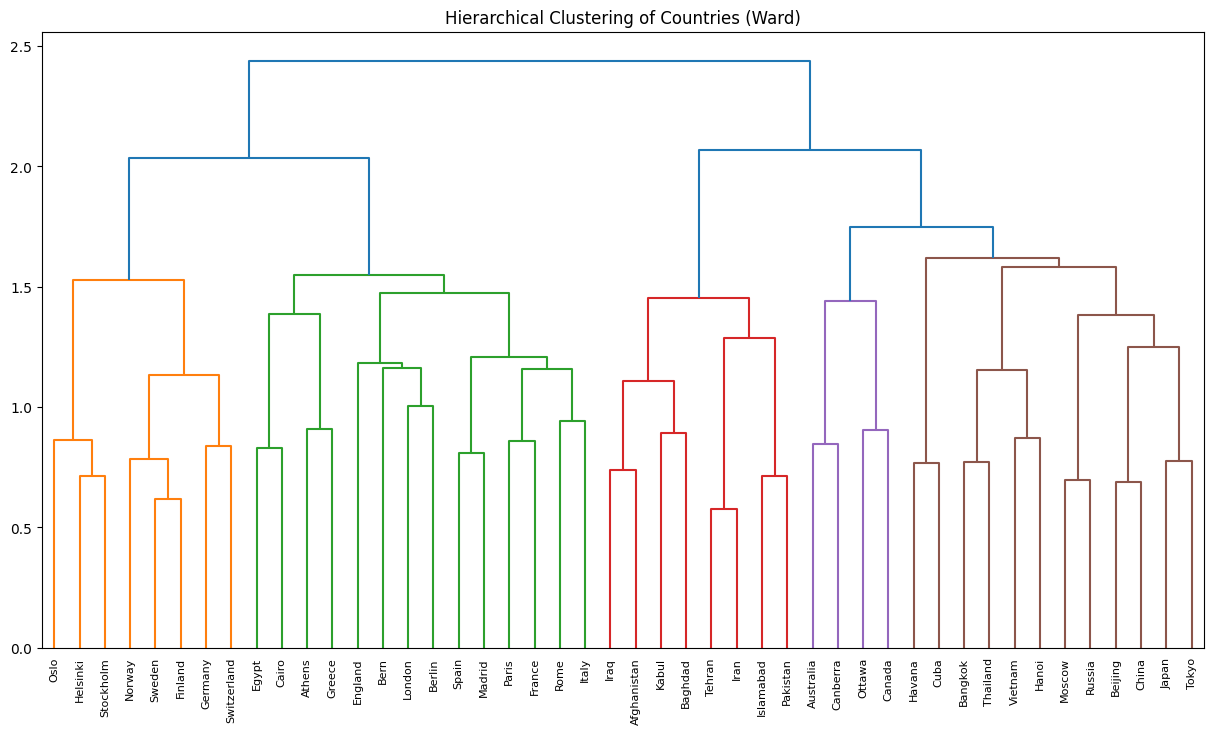

In [48]:
plt.figure(figsize=(15, 8))

dendrogram(
    Z,
    labels=valid_countries,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering of Countries (Ward)")
plt.show()

## 59. t-SNEによる可視化

ベクトル空間上の国名に関する単語ベクトルをt-SNEで可視化せよ。

## 59. Trực quan hóa bằng t-SNE

Hãy dùng:

- t-SNE

để trực quan hóa các vector quốc gia trong không gian vector.

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

country_vectors = []
valid_countries = []

for c in countries:
    try:
        country_vectors.append(model[c])
        valid_countries.append(c)
    except KeyError:
        continue

X = np.array(country_vectors)

In [51]:
tsne = TSNE(
    n_components=2,
    random_state=0,
    perplexity=10
)

X_2d = tsne.fit_transform(X)

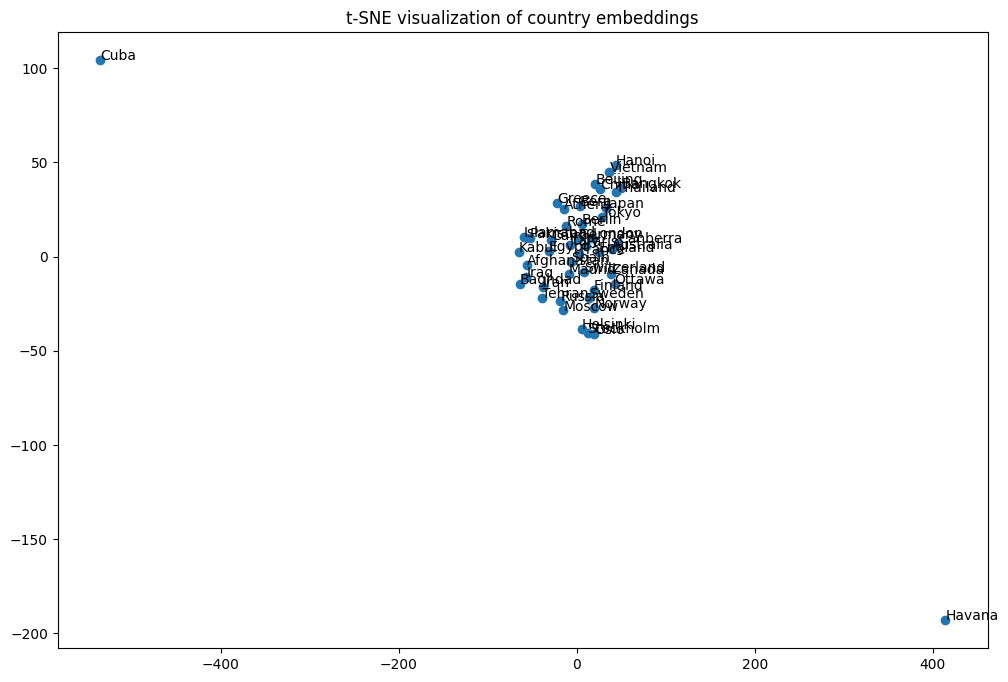

In [52]:
plt.figure(figsize=(12, 8))

plt.scatter(X_2d[:, 0], X_2d[:, 1])

for i, country in enumerate(valid_countries):
    plt.text(X_2d[i, 0], X_2d[i, 1], country)

plt.title("t-SNE visualization of country embeddings")
plt.show()